# Terna electricity by source - preanalysis v1

**Discussion di riferimento:** https://github.com/orgs/dataciviclab/discussions/115

**Domanda pubblica:** Il mix elettrico italiano si sta spostando dalle fonti fossili?

**Sottodomande**
- il peso del termoelettrico cala in modo leggibile nel 2020-2024?
- il 2024 segnala uno spostamento strutturale oppure soprattutto un rimbalzo dopo un anno anomalo?
- dove cresce di più il fotovoltaico?
- quanto pesa davvero l'idroelettrico nel riequilibrio degli ultimi anni?

**Perimetro**
- produzione `Netta`
- livello `anno x regione x fonte`
- dicembre `2020-2024`

**Obiettivo di questa versione**
- non solo mostrare i movimenti del mix
- ma distinguere meglio tra segnali più strutturali e componenti più volatili


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
REPO_ROOT = PROJECT_DIR.parents[2]
MART_DIR = REPO_ROOT / "out" / "data" / "mart" / "terna_electricity_by_source"
CLEAN_DIR = REPO_ROOT / "out" / "data" / "clean" / "terna_electricity_by_source"
YEARS = [2020, 2021, 2022, 2023, 2024]

COLOR_MAP = {
    "Termoelettrico": "#b23a48",
    "Idrico": "#3f88c5",
    "Fotovoltaico": "#f2c14e",
    "Eolico": "#4d9078",
    "Geotermoelettrico": "#7d5ba6",
    "Accumulo Stand Alone": "#5c677d",
    "non_fossile_excl_idrico_pct": "#1f7a8c",
}

PROFILE_COLORS = {
    "ancora molto termoelettrica": "#b23a48",
    "riequilibrio trainato dal fotovoltaico": "#f2c14e",
    "mix mosso soprattutto dall'idroelettrico": "#3f88c5",
    "profilo misto/intermedio": "#6c757d",
}

mart_frames = []
for year in YEARS:
    path = MART_DIR / str(year) / "mart_mix_regioni.parquet"
    mart_frames.append(pd.read_parquet(path))

mart = pd.concat(mart_frames, ignore_index=True)

clean_frames = []
for year in YEARS:
    path = CLEAN_DIR / str(year) / f"terna_electricity_by_source_{year}_clean.parquet"
    clean_frames.append(pd.read_parquet(path))

clean = pd.concat(clean_frames, ignore_index=True)

national = (
    mart.groupby(["anno", "fonte"], as_index=False)["produzione_gwh_netta"]
    .sum()
)
national["totale_nazionale_gwh"] = national.groupby("anno")["produzione_gwh_netta"].transform("sum")
national["quota_nazionale_pct"] = (
    national["produzione_gwh_netta"] / national["totale_nazionale_gwh"] * 100
)

pivot_national = (
    national.pivot(index="anno", columns="fonte", values="quota_nazionale_pct")
    .fillna(0)
    .reset_index()
)
pivot_national.columns.name = None
pivot_national["non_fossile_excl_idrico_pct"] = (
    pivot_national[["Fotovoltaico", "Eolico", "Geotermoelettrico", "Accumulo Stand Alone"]]
    .sum(axis=1)
)
pivot_national["non_fossile_totale_pct"] = (
    pivot_national[["Idrico", "Fotovoltaico", "Eolico", "Geotermoelettrico", "Accumulo Stand Alone"]]
    .sum(axis=1)
)

delta_sources = pd.DataFrame(
    {
        "fonte": [
            "Termoelettrico",
            "Idrico",
            "Fotovoltaico",
            "Eolico",
            "Geotermoelettrico",
            "non_fossile_excl_idrico_pct",
        ],
        "delta_2020_2024_pp": [
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Termoelettrico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2020, "Termoelettrico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Idrico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2020, "Idrico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Fotovoltaico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2020, "Fotovoltaico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Eolico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2020, "Eolico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Geotermoelettrico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2020, "Geotermoelettrico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "non_fossile_excl_idrico_pct"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2020, "non_fossile_excl_idrico_pct"].iloc[0]),
        ],
        "delta_2022_2024_pp": [
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Termoelettrico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2022, "Termoelettrico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Idrico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2022, "Idrico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Fotovoltaico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2022, "Fotovoltaico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Eolico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2022, "Eolico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "Geotermoelettrico"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2022, "Geotermoelettrico"].iloc[0]),
            float(pivot_national.loc[pivot_national["anno"] == 2024, "non_fossile_excl_idrico_pct"].iloc[0] - pivot_national.loc[pivot_national["anno"] == 2022, "non_fossile_excl_idrico_pct"].iloc[0]),
        ],
    }
).round(2)

snapshot_2324 = (
    pivot_national.loc[pivot_national["anno"].isin([2023, 2024]), [
        "anno",
        "Termoelettrico",
        "Idrico",
        "Fotovoltaico",
        "Eolico",
        "Geotermoelettrico",
        "Accumulo Stand Alone",
    ]]
    .copy()
)
snapshot_2324_long = snapshot_2324.melt(id_vars="anno", var_name="fonte", value_name="quota_pct")
snapshot_2324_table = (
    snapshot_2324_long.pivot(index="fonte", columns="anno", values="quota_pct")
    .fillna(0)
    .reset_index()
)
snapshot_2324_table["delta_2024_vs_2023_pp"] = (
    snapshot_2324_table[2024] - snapshot_2324_table[2023]
).round(2)
snapshot_2324_table = snapshot_2324_table.sort_values(2024, ascending=False).reset_index(drop=True)

regional = (
    mart.pivot(index=["regione", "fonte"], columns="anno", values="quota_mix_regionale_pct")
    .reset_index()
    .fillna(0)
)
regional.columns.name = None

regional_delta_2324 = regional[["regione", "fonte", 2023, 2024]].copy()
regional_delta_2324 = regional_delta_2324.rename(columns={2023: "quota_2023", 2024: "quota_2024"})
regional_delta_2324["delta_2024_vs_2023_pp"] = (
    regional_delta_2324["quota_2024"] - regional_delta_2324["quota_2023"]
).round(2)
top_up_2324 = regional_delta_2324.sort_values("delta_2024_vs_2023_pp", ascending=False).head(6).reset_index(drop=True)
top_down_2324 = regional_delta_2324.sort_values("delta_2024_vs_2023_pp", ascending=True).head(6).reset_index(drop=True)

termoelettrico = regional[regional["fonte"] == "Termoelettrico"][["regione", 2020, 2021, 2022, 2023, 2024]].copy()
termoelettrico = termoelettrico.rename(
    columns={
        2020: "termo_2020",
        2021: "termo_2021",
        2022: "termo_2022",
        2023: "termo_2023",
        2024: "termo_2024",
    }
)
termoelettrico["delta_termo_2020_2024"] = (termoelettrico["termo_2024"] - termoelettrico["termo_2020"]).round(2)
termoelettrico["delta_termo_2022_2024"] = (termoelettrico["termo_2024"] - termoelettrico["termo_2022"]).round(2)

fotovoltaico = regional[regional["fonte"] == "Fotovoltaico"][["regione", 2020, 2024]].copy()
fotovoltaico = fotovoltaico.rename(columns={2020: "foto_2020", 2024: "foto_2024"})
fotovoltaico["delta_foto_2020_2024"] = (fotovoltaico["foto_2024"] - fotovoltaico["foto_2020"]).round(2)

idrico = regional[regional["fonte"] == "Idrico"][["regione", 2020, 2021, 2022, 2023, 2024]].copy()
idrico = idrico.rename(
    columns={
        2020: "idr_2020",
        2021: "idr_2021",
        2022: "idr_2022",
        2023: "idr_2023",
        2024: "idr_2024",
    }
)
idrico["idr_range_pp"] = (
    idrico[["idr_2020", "idr_2021", "idr_2022", "idr_2023", "idr_2024"]].max(axis=1)
    - idrico[["idr_2020", "idr_2021", "idr_2022", "idr_2023", "idr_2024"]].min(axis=1)
).round(2)

profiles = (
    termoelettrico
    .merge(fotovoltaico, on="regione", how="left")
    .merge(idrico, on="regione", how="left")
)
profiles["profile"] = "profilo misto/intermedio"
profiles.loc[profiles["termo_2024"] >= 60, "profile"] = "ancora molto termoelettrica"
profiles.loc[
    (profiles["delta_foto_2020_2024"] >= 6) & (profiles["termo_2024"] < 60),
    "profile",
] = "riequilibrio trainato dal fotovoltaico"
profiles.loc[
    (profiles["idr_range_pp"] >= 10)
    & (profiles["delta_foto_2020_2024"] < 6)
    & (profiles["termo_2024"] < 60),
    "profile",
] = "mix mosso soprattutto dall'idroelettrico"

profile_tables = {}
for profile_name in [
    "ancora molto termoelettrica",
    "riequilibrio trainato dal fotovoltaico",
    "mix mosso soprattutto dall'idroelettrico",
]:
    profile_tables[profile_name] = (
        profiles.loc[profiles["profile"] == profile_name, [
            "regione",
            "termo_2024",
            "delta_termo_2020_2024",
            "delta_foto_2020_2024",
            "idr_range_pp",
        ]]
        .sort_values("termo_2024", ascending=False)
        .reset_index(drop=True)
    )

annual_tipo = (
    clean.groupby(["anno", "tipo_produzione"], as_index=False)["produzione_gwh"]
    .sum()
    .sort_values(["anno", "tipo_produzione"])
)
annual_tipo_pivot = annual_tipo.pivot(index="anno", columns="tipo_produzione", values="produzione_gwh").reset_index()
annual_tipo_pivot.columns.name = None
annual_tipo_pivot["delta_lorda_vs_netta"] = (annual_tipo_pivot["Lorda"] - annual_tipo_pivot["Netta"]).round(6)

granular_tipo = (
    clean.groupby(["anno", "regione", "fonte", "tipo_produzione"], as_index=False)["produzione_gwh"]
    .sum()
)
granular_tipo_pivot = granular_tipo.pivot(
    index=["anno", "regione", "fonte"],
    columns="tipo_produzione",
    values="produzione_gwh",
).reset_index()
granular_tipo_pivot.columns.name = None
granular_tipo_pivot["delta_abs"] = (granular_tipo_pivot["Lorda"] - granular_tipo_pivot["Netta"]).round(6)
granular_tipo_pivot["delta_rel_pct"] = (
    (granular_tipo_pivot["Lorda"] - granular_tipo_pivot["Netta"])
    / granular_tipo_pivot["Netta"]
    * 100
).fillna(0)

granular_check = pd.DataFrame(
    {
        "metrica": [
            "confronti anno-regione-fonte",
            "delta assoluto massimo",
            "delta relativo massimo (%)",
            "righe con delta assoluto non nullo",
        ],
        "valore": [
            len(granular_tipo_pivot),
            round(float(granular_tipo_pivot["delta_abs"].abs().max()), 6),
            round(float(granular_tipo_pivot["delta_rel_pct"].abs().max()), 12),
            int((granular_tipo_pivot["delta_abs"].abs() > 1e-9).sum()),
        ],
    }
)


## 0. Punto di partenza già condiviso pubblicamente

Prima della serie `2020-2024`, avevamo già condiviso in `#108` una prima lettura più stretta sul confronto `2023 -> 2024`.
La riporto qui dentro per due motivi:

- mantiene continuità con il materiale già discusso pubblicamente;
- aiuta a vedere come il `v1` esteso nasce da un primo segnale già leggibile, non da una riscrittura da zero.


anno,fonte,2023,2024,delta_2024_vs_2023_pp
0,Termoelettrico,61.42,56.13,-5.30
1,Idrico,15.89,20.21,4.32
2,Fotovoltaico,11.60,13.28,1.68
3,Eolico,8.93,8.24,-0.69
4,Geotermoelettrico,2.15,2.09,-0.06
5,Accumulo Stand Alone,0.00,0.05,0.05


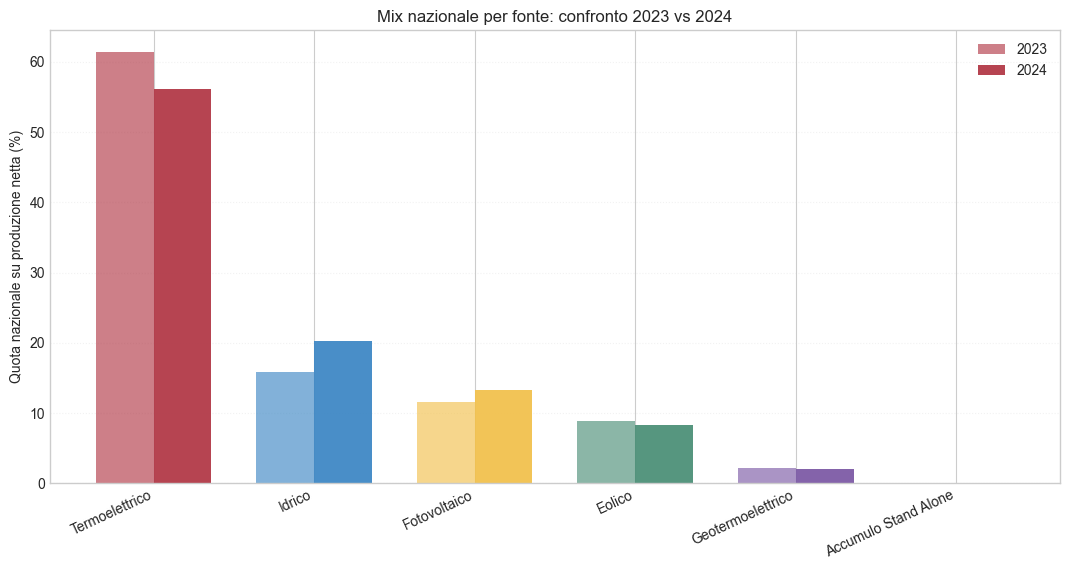

In [2]:
display(snapshot_2324_table.round(2))

fig, ax = plt.subplots(figsize=(10.8, 5.8))
x = range(len(snapshot_2324_table))
colors = [COLOR_MAP.get(fonte, "#6c757d") for fonte in snapshot_2324_table["fonte"]]
ax.bar([i - 0.18 for i in x], snapshot_2324_table[2023], width=0.36, label="2023", color=colors, alpha=0.65)
ax.bar([i + 0.18 for i in x], snapshot_2324_table[2024], width=0.36, label="2024", color=colors, alpha=0.95)
ax.set_xticks(list(x))
ax.set_xticklabels(snapshot_2324_table["fonte"], rotation=25, ha="right")
ax.set_ylabel("Quota nazionale su produzione netta (%)")
ax.set_title("Mix nazionale per fonte: confronto 2023 vs 2024")
ax.grid(axis="y", alpha=0.25, linestyle=":")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Principali spostamenti regionali 2023 -> 2024

#### Incrementi più forti

,regione,fonte,quota_2023,quota_2024,delta_2024_vs_2023_pp
0,Molise,Termoelettrico,39.45,58.37,18.92
1,Campania,Termoelettrico,44.33,59.73,15.40
2,Lazio,Fotovoltaico,20.72,34.09,13.37
3,Friuli-Venezia Giulia,Idrico,20.05,32.34,12.29
4,Piemonte,Idrico,22.02,31.80,9.78
5,Abruzzo,Termoelettrico,41.75,49.89,8.14


#### Riduzioni più forti

,regione,fonte,quota_2023,quota_2024,delta_2024_vs_2023_pp
0,Friuli-Venezia Giulia,Termoelettrico,70.13,52.94,-17.19
1,Molise,Eolico,38.05,25.42,-12.63
2,Lazio,Termoelettrico,68.30,56.20,-12.10
3,Campania,Eolico,36.87,25.41,-11.46
4,Sicilia,Termoelettrico,66.24,55.63,-10.61
5,Piemonte,Termoelettrico,68.68,58.19,-10.49


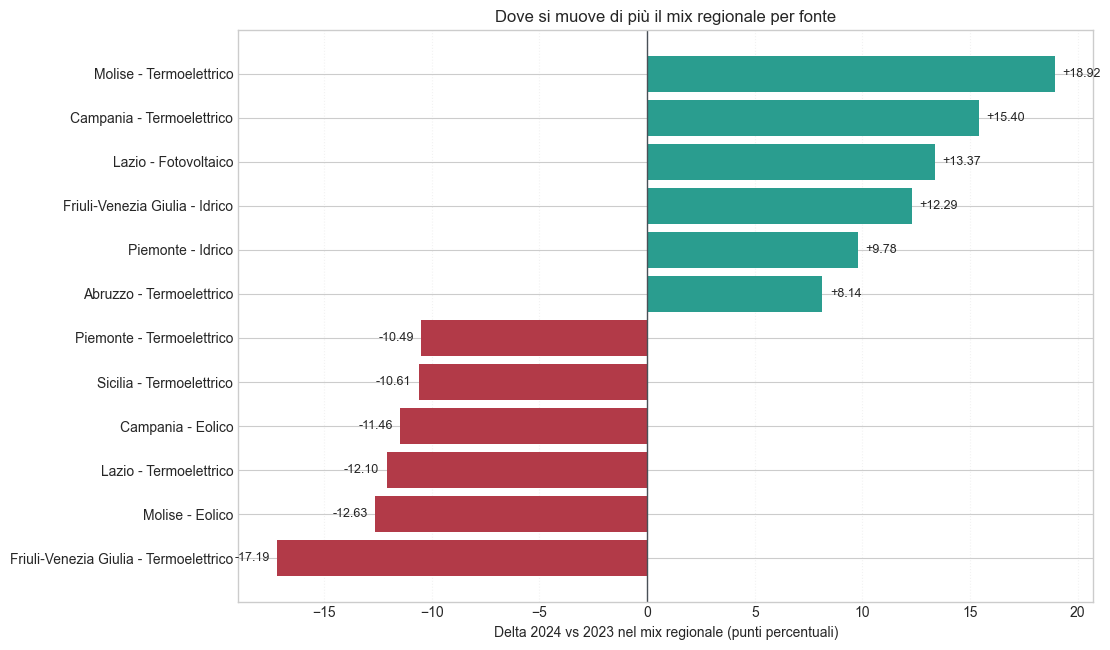

In [3]:
display(Markdown("### Principali spostamenti regionali 2023 -> 2024"))
display(Markdown("#### Incrementi più forti"))
display(top_up_2324)
display(Markdown("#### Riduzioni più forti"))
display(top_down_2324)

plot_moves = pd.concat([top_up_2324, top_down_2324], ignore_index=True).copy()
plot_moves["label"] = plot_moves["regione"] + " - " + plot_moves["fonte"]
plot_moves = plot_moves.sort_values("delta_2024_vs_2023_pp", ascending=True)
plot_moves["color"] = plot_moves["delta_2024_vs_2023_pp"].apply(lambda v: "#2a9d8f" if v > 0 else "#b23a48")

fig, ax = plt.subplots(figsize=(11.2, 6.6))
bars = ax.barh(plot_moves["label"], plot_moves["delta_2024_vs_2023_pp"], color=plot_moves["color"])
ax.axvline(0, color="#495057", linewidth=1)
ax.set_xlabel("Delta 2024 vs 2023 nel mix regionale (punti percentuali)")
ax.set_title("Dove si muove di più il mix regionale per fonte")
ax.grid(axis="x", alpha=0.25, linestyle=":")

for bar, value in zip(bars, plot_moves["delta_2024_vs_2023_pp"]):
    x = value + 0.35 if value >= 0 else value - 0.35
    ha = "left" if value >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height() / 2, f"{value:+.2f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()


## 1. Pattern nazionale

Il primo punto da chiarire non è solo **se** il termoelettrico cali, ma **come** ci arriva.
Con la serie `2020-2024`, il quadro è meno fragile del semplice confronto `2023-2024`:

- il termoelettrico scende nel complesso, ma non in modo lineare;
- il `2022` appare come un anno di forte ritorno ai fossili;
- il `2024` va quindi letto insieme a due segnali diversi:
  - rimbalzo dell'idroelettrico dopo un anno molto debole;
  - crescita più graduale delle fonti non fossili meno dipendenti dall'acqua.


,anno,Termoelettrico,Idrico,Fotovoltaico,Eolico,Geotermoelettrico,non_fossile_excl_idrico_pct,non_fossile_totale_pct
0,2020,64.63,17.64,8.89,6.69,2.15,17.73,35.37
1,2021,65.63,16.42,8.66,7.24,2.05,17.95,34.37
2,2022,70.16,10.67,9.90,7.22,2.06,19.18,29.84
3,2023,61.42,15.89,11.60,8.93,2.15,22.69,38.58
4,2024,56.13,20.21,13.28,8.24,2.09,23.67,43.87


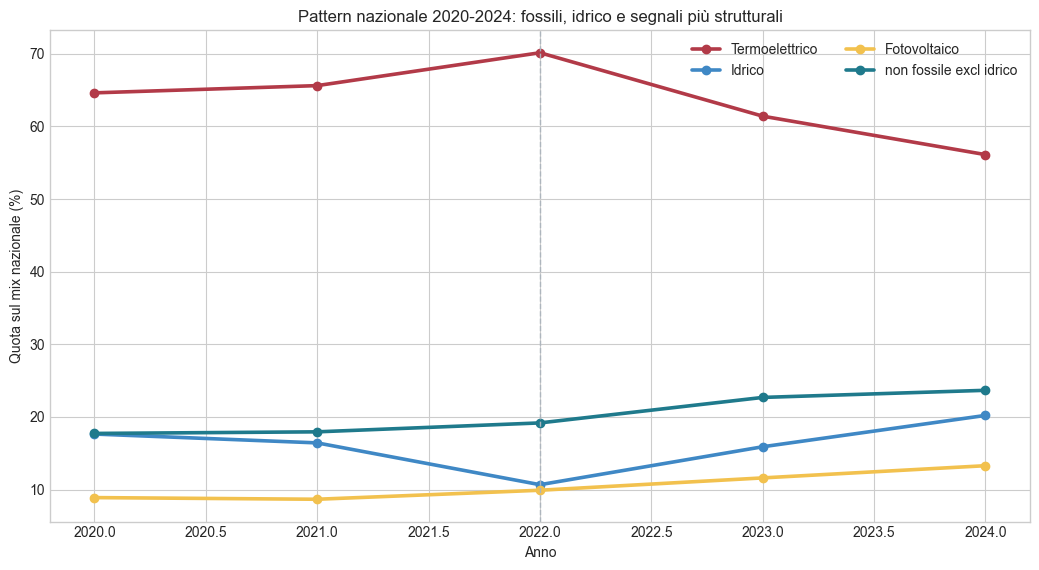

In [4]:
national_view = pivot_national[
    [
        "anno",
        "Termoelettrico",
        "Idrico",
        "Fotovoltaico",
        "Eolico",
        "Geotermoelettrico",
        "non_fossile_excl_idrico_pct",
        "non_fossile_totale_pct",
    ]
].round(2)
display(national_view)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for serie in [
    "Termoelettrico",
    "Idrico",
    "Fotovoltaico",
    "non_fossile_excl_idrico_pct",
]:
    label = serie.replace("_pct", "").replace("_", " ")
    ax.plot(
        pivot_national["anno"],
        pivot_national[serie],
        marker="o",
        linewidth=2.6,
        label=label,
        color=COLOR_MAP.get(serie, "#495057"),
    )

ax.axvline(2022, color="#adb5bd", linestyle="--", linewidth=1)
ax.set_title("Pattern nazionale 2020-2024: fossili, idrico e segnali più strutturali")
ax.set_xlabel("Anno")
ax.set_ylabel("Quota sul mix nazionale (%)")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


In [5]:
termo_2020 = float(pivot_national.loc[pivot_national["anno"] == 2020, "Termoelettrico"].iloc[0])
termo_2022 = float(pivot_national.loc[pivot_national["anno"] == 2022, "Termoelettrico"].iloc[0])
termo_2024 = float(pivot_national.loc[pivot_national["anno"] == 2024, "Termoelettrico"].iloc[0])
idrico_2022 = float(pivot_national.loc[pivot_national["anno"] == 2022, "Idrico"].iloc[0])
idrico_2024 = float(pivot_national.loc[pivot_national["anno"] == 2024, "Idrico"].iloc[0])
non_idrico_2020 = float(pivot_national.loc[pivot_national["anno"] == 2020, "non_fossile_excl_idrico_pct"].iloc[0])
non_idrico_2024 = float(pivot_national.loc[pivot_national["anno"] == 2024, "non_fossile_excl_idrico_pct"].iloc[0])

national_comment = f'''
### Lettura del pattern nazionale

- il **termoelettrico** passa dal **{termo_2020:.2f}%** del 2020 al **{termo_2024:.2f}%** del 2024 (**{termo_2024 - termo_2020:+.2f} pp**);
- però il punto più alto della serie è il **2022**, quando arriva al **{termo_2022:.2f}%**;
- nello stesso intervallo l'**idroelettrico** passa dal **{idrico_2022:.2f}%** del 2022 al **{idrico_2024:.2f}%** del 2024 (**{idrico_2024 - idrico_2022:+.2f} pp**);
- le fonti **non fossili diverse dall'idrico** crescono comunque dal **{non_idrico_2020:.2f}%** del 2020 al **{non_idrico_2024:.2f}%** del 2024 (**{non_idrico_2024 - non_idrico_2020:+.2f} pp**).

Quindi il `2024` non sembra soltanto un rimbalzo dopo un anno anomalo:
dentro il riequilibrio c'è anche una componente più graduale e più strutturale.
'''

display(Markdown(national_comment))



### Lettura del pattern nazionale

- il **termoelettrico** passa dal **64.63%** del 2020 al **56.13%** del 2024 (**-8.50 pp**);
- però il punto più alto della serie è il **2022**, quando arriva al **70.16%**;
- nello stesso intervallo l'**idroelettrico** passa dal **10.67%** del 2022 al **20.21%** del 2024 (**+9.54 pp**);
- le fonti **non fossili diverse dall'idrico** crescono comunque dal **17.73%** del 2020 al **23.67%** del 2024 (**+5.94 pp**).

Quindi il `2024` non sembra soltanto un rimbalzo dopo un anno anomalo:
dentro il riequilibrio c'è anche una componente più graduale e più strutturale.


## 2. Fotovoltaico e idroelettrico non dicono la stessa cosa

Se ci fermiamo al calo del termoelettrico rischiamo di leggere insieme due fenomeni diversi:

- il **fotovoltaico**, che cresce in modo più ordinato nel tempo;
- l'**idroelettrico**, che pesa molto ma si muove con maggiore volatilità.

Distinguere questi due piani serve a non sovrainterpretare il riequilibrio del `2024`.


,fonte,delta_2020_2024_pp,delta_2022_2024_pp
1,Idrico,2.56,9.54
5,non_fossile_excl_idrico_pct,5.94,4.49
2,Fotovoltaico,4.39,3.38
3,Eolico,1.55,1.02
4,Geotermoelettrico,-0.05,0.04
0,Termoelettrico,-8.50,-14.03


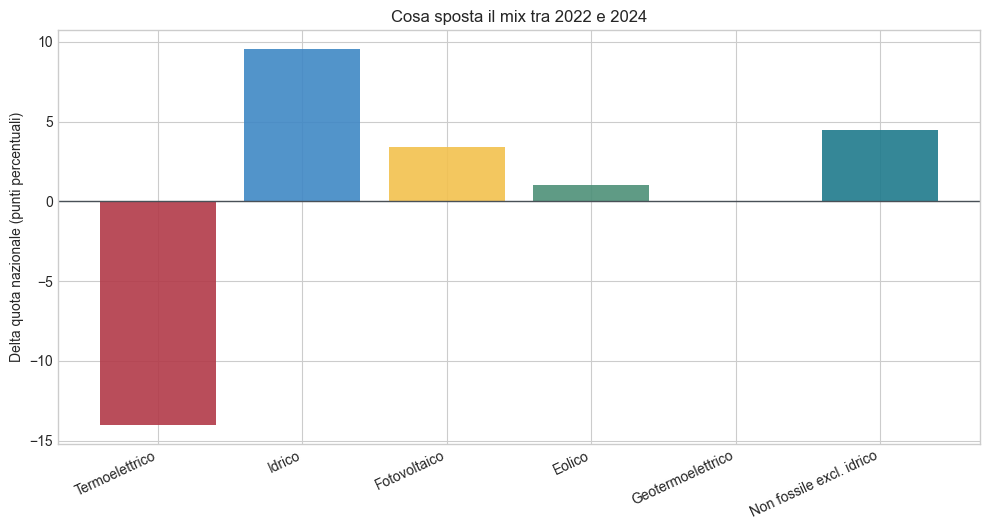

In [6]:
display(delta_sources.sort_values("delta_2022_2024_pp", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5.4))
plot_df = delta_sources.copy()
plot_df["label"] = plot_df["fonte"].replace({"non_fossile_excl_idrico_pct": "Non fossile excl. idrico"})
ax.bar(
    plot_df["label"],
    plot_df["delta_2022_2024_pp"],
    color=[COLOR_MAP.get(v, "#6c757d") for v in plot_df["fonte"]],
    alpha=0.9,
)
ax.set_title("Cosa sposta il mix tra 2022 e 2024")
ax.set_ylabel("Delta quota nazionale (punti percentuali)")
ax.axhline(0, color="#495057", linewidth=1)
ax.tick_params(axis="x", labelrotation=25)
for label in ax.get_xticklabels():
    label.set_ha("right")
plt.tight_layout()
plt.show()


In [7]:
foto_2020 = float(pivot_national.loc[pivot_national["anno"] == 2020, "Fotovoltaico"].iloc[0])
foto_2024 = float(pivot_national.loc[pivot_national["anno"] == 2024, "Fotovoltaico"].iloc[0])

role_comment = f'''
### Come leggere fotovoltaico e idroelettrico

- il **fotovoltaico** passa dall'**{foto_2020:.2f}%** del 2020 al **{foto_2024:.2f}%** del 2024 (**{foto_2024 - foto_2020:+.2f} pp**);
- l'**idroelettrico** cresce meno sul confronto 2020-2024, ma domina molto di più il rimbalzo `2022 -> 2024`;
- per questo il fotovoltaico sembra il segnale più strutturale del riequilibrio non fossile,
  mentre l'idroelettrico va trattato come componente importante ma più instabile.
'''

display(Markdown(role_comment))



### Come leggere fotovoltaico e idroelettrico

- il **fotovoltaico** passa dall'**8.89%** del 2020 al **13.28%** del 2024 (**+4.39 pp**);
- l'**idroelettrico** cresce meno sul confronto 2020-2024, ma domina molto di più il rimbalzo `2022 -> 2024`;
- per questo il fotovoltaico sembra il segnale più strutturale del riequilibrio non fossile,
  mentre l'idroelettrico va trattato come componente importante ma più instabile.


## 3. Una lettura regionale più ordinata

Per non restare ai soli ranking, qui usiamo una tipologia euristica minima.
Non è una tassonomia “vera”, ma aiuta a separare almeno tre profili:

- regioni ancora molto termoelettriche nel `2024`;
- regioni in riequilibrio trainato soprattutto dal fotovoltaico;
- regioni dove il mix appare mosso più dalla volatilità idrica.


,regione,profile,termo_2024,delta_termo_2020_2024,delta_foto_2020_2024,idr_range_pp
0,Emilia-Romagna,ancora molto termoelettrica,79.05,-6.31,4.94,3.23
1,Calabria,ancora molto termoelettrica,70.75,-7.09,2.77,1.85
2,Sardegna,ancora molto termoelettrica,67.42,-7.77,5.78,1.84
3,Lombardia,ancora molto termoelettrica,65.78,-6.20,2.92,12.90
4,Liguria,ancora molto termoelettrica,65.50,-15.01,3.45,9.66
5,Piemonte,mix mosso soprattutto dall'idroelettrico,58.19,-9.89,3.62,15.76
6,Veneto,mix mosso soprattutto dall'idroelettrico,49.82,-1.71,4.68,16.85
7,Campania,profilo misto/intermedio,59.73,2.60,1.56,3.53
8,Puglia,profilo misto/intermedio,59.26,-11.46,4.94,0.00
9,Molise,profilo misto/intermedio,58.37,-8.37,3.49,5.36


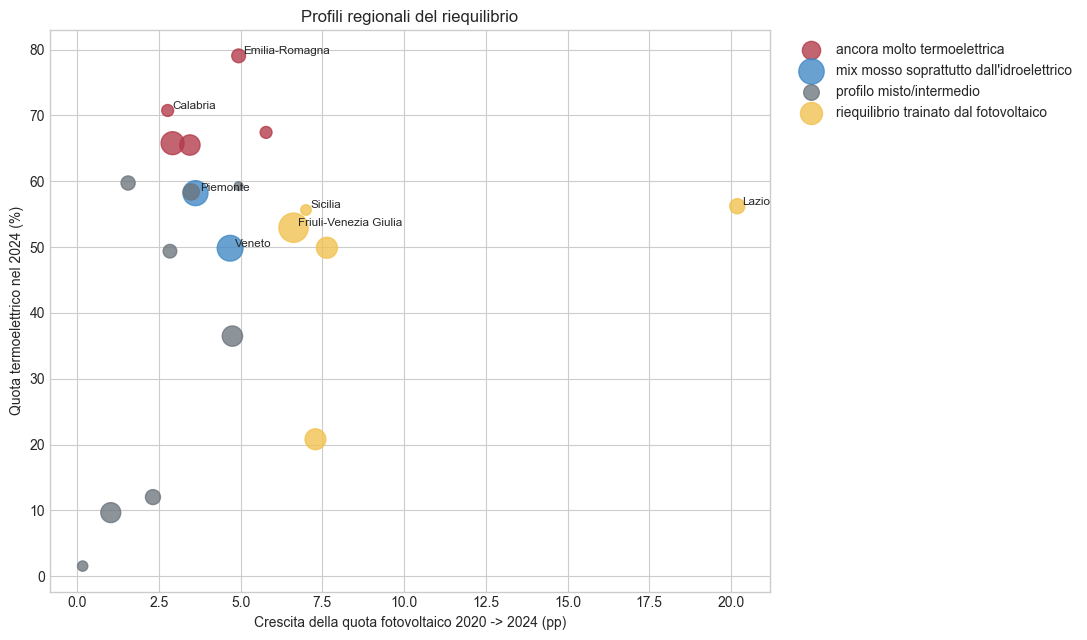

#### ancora molto termoelettrica

,regione,termo_2024,delta_termo_2020_2024,delta_foto_2020_2024,idr_range_pp
0,Emilia-Romagna,79.05,-6.31,4.94,3.23
1,Calabria,70.75,-7.09,2.77,1.85
2,Sardegna,67.42,-7.77,5.78,1.84
3,Lombardia,65.78,-6.20,2.92,12.90
4,Liguria,65.50,-15.01,3.45,9.66


#### riequilibrio trainato dal fotovoltaico

,regione,termo_2024,delta_termo_2020_2024,delta_foto_2020_2024,idr_range_pp
0,Lazio,56.20,-21.87,20.19,4.36
1,Sicilia,55.63,-12.87,7.00,0.96
2,Friuli-Venezia Giulia,52.94,-15.38,6.62,22.47
3,Abruzzo,49.89,-10.42,7.64,10.40
4,Marche,20.80,-1.42,7.29,10.27


#### mix mosso soprattutto dall'idroelettrico

,regione,termo_2024,delta_termo_2020_2024,delta_foto_2020_2024,idr_range_pp
0,Piemonte,58.19,-9.89,3.62,15.76
1,Veneto,49.82,-1.71,4.68,16.85


In [8]:
profile_view = profiles[
    [
        "regione",
        "profile",
        "termo_2024",
        "delta_termo_2020_2024",
        "delta_foto_2020_2024",
        "idr_range_pp",
    ]
].sort_values(["profile", "termo_2024"], ascending=[True, False])
display(profile_view.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(11, 6.5))
for profile_name, group in profiles.groupby("profile"):
    ax.scatter(
        group["delta_foto_2020_2024"],
        group["termo_2024"],
        s=group["idr_range_pp"] * 18 + 40,
        color=PROFILE_COLORS[profile_name],
        alpha=0.78,
        label=profile_name,
    )

labels = {
    "Emilia-Romagna",
    "Calabria",
    "Lazio",
    "Sicilia",
    "Friuli-Venezia Giulia",
    "Piemonte",
    "Veneto",
}
for _, row in profiles.iterrows():
    if row["regione"] in labels:
        ax.text(
            row["delta_foto_2020_2024"] + 0.15,
            row["termo_2024"] + 0.25,
            row["regione"],
            fontsize=8.5,
        )

ax.set_title("Profili regionali del riequilibrio")
ax.set_xlabel("Crescita della quota fotovoltaico 2020 -> 2024 (pp)")
ax.set_ylabel("Quota termoelettrico nel 2024 (%)")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

for profile_name in [
    "ancora molto termoelettrica",
    "riequilibrio trainato dal fotovoltaico",
    "mix mosso soprattutto dall'idroelettrico",
]:
    display(Markdown(f"#### {profile_name}"))
    display(profile_tables[profile_name])


In [9]:
regional_comment = '''
La lettura regionale che emerge è questa:

- il blocco ancora più termoelettrico resta molto visibile, con **Emilia-Romagna, Calabria, Sardegna, Lombardia e Liguria**;
- il caso più netto di riequilibrio trainato dal fotovoltaico è il **Lazio**, ma segnali simili si vedono anche in **Sicilia, Abruzzo e Marche**;
- **Friuli-Venezia Giulia, Veneto e Piemonte** mostrano invece profili in cui il ruolo dell'idroelettrico resta molto forte e più instabile.

Questo aiuta a evitare una lettura unica del dato regionale: il riequilibrio non segue la stessa logica ovunque.
'''

display(Markdown(regional_comment))



La lettura regionale che emerge è questa:

- il blocco ancora più termoelettrico resta molto visibile, con **Emilia-Romagna, Calabria, Sardegna, Lombardia e Liguria**;
- il caso più netto di riequilibrio trainato dal fotovoltaico è il **Lazio**, ma segnali simili si vedono anche in **Sicilia, Abruzzo e Marche**;
- **Friuli-Venezia Giulia, Veneto e Piemonte** mostrano invece profili in cui il ruolo dell'idroelettrico resta molto forte e più instabile.

Questo aiuta a evitare una lettura unica del dato regionale: il riequilibrio non segue la stessa logica ovunque.


## 4. Check metodologico su `Netta` vs `Lorda`

Fin qui il mart usa `Netta`, ma il dubbio va chiuso meglio:
se `Lorda` e `Netta` coincidono solo sui totali annuali, la nota metodologica resta debole;
se coincidono anche nel taglio `anno x regione x fonte`, il perimetro è molto più difendibile.


In [10]:
display(annual_tipo_pivot.round(6))
display(granular_check)


,anno,Lorda,Netta,delta_lorda_vs_netta
0,2020,280531.014218,280531.014218,0.0
1,2021,289069.525464,289069.525464,0.0
2,2022,283953.030623,283953.030623,0.0
3,2023,264708.092024,264708.092024,0.0
4,2024,270963.087787,270963.087787,0.0


,metrica,valore
0,confronti anno-regione-fonte,429.0
1,delta assoluto massimo,0.0
2,delta relativo massimo (%),0.0
3,righe con delta assoluto non nullo,0.0


In [11]:
methodology_comment = f'''
### Esito del check `Netta` vs `Lorda`

- sui totali annuali `2020-2024`, `Lorda` e `Netta` coincidono sempre;
- anche sul taglio **anno x regione x fonte** non emergono differenze sostanziali:
  il delta assoluto massimo osservato è **{float(granular_check.loc[granular_check['metrica'] == 'delta assoluto massimo', 'valore'].iloc[0]):.6f}**;
- le righe con delta assoluto non nullo sono **{int(granular_check.loc[granular_check['metrica'] == 'righe con delta assoluto non nullo', 'valore'].iloc[0])}** su **{int(granular_check.loc[granular_check['metrica'] == 'confronti anno-regione-fonte', 'valore'].iloc[0])}**.

Nel perimetro osservato, quindi, usare `Netta` come taglio principale non sembra introdurre una distorsione visibile.
'''

display(Markdown(methodology_comment))



### Esito del check `Netta` vs `Lorda`

- sui totali annuali `2020-2024`, `Lorda` e `Netta` coincidono sempre;
- anche sul taglio **anno x regione x fonte** non emergono differenze sostanziali:
  il delta assoluto massimo osservato è **0.000000**;
- le righe con delta assoluto non nullo sono **0** su **429**.

Nel perimetro osservato, quindi, usare `Netta` come taglio principale non sembra introdurre una distorsione visibile.


In [12]:
top_termo_row = profiles.sort_values("termo_2024", ascending=False).iloc[0]
top_foto_row = profiles.sort_values("delta_foto_2020_2024", ascending=False).iloc[0]
top_idrico_row = profiles.sort_values("idr_range_pp", ascending=False).iloc[0]

summary = f'''
## Risposta sintetica v1

**Il mix elettrico italiano si sta spostando dalle fonti fossili?**

Sì, ma non in modo lineare.
Il **termoelettrico** scende dal **{termo_2020:.2f}%** del 2020 al **{termo_2024:.2f}%** del 2024 (**{termo_2024 - termo_2020:+.2f} pp**),
ma nel mezzo il **2022** resta un anno molto più fossile del resto della serie.

**Come va letto il 2024?**

Non solo come rimbalzo dopo un anno anomalo.
L'idroelettrico pesa molto nel riequilibrio, ma cresce anche il blocco non fossile meno volatile:
le fonti non fossili **al netto dell'idrico** passano dal **{non_idrico_2020:.2f}%** al **{non_idrico_2024:.2f}%**.

**Che cosa distingue i segnali non fossili?**

- il **fotovoltaico** è il segnale più ordinato e più strutturale;
- l'**idroelettrico** è il segnale più forte ma anche più instabile.

**Cosa succede nei territori?**

- la regione più termoelettrica nel 2024 è **{top_termo_row['regione']}** (**{top_termo_row['termo_2024']:.2f}%**);
- il caso più netto di crescita fotovoltaica è **{top_foto_row['regione']}** (**{top_foto_row['delta_foto_2020_2024']:+.2f} pp**);
- il caso più esposto alla volatilità idrica è **{top_idrico_row['regione']}** (**range {top_idrico_row['idr_range_pp']:.2f} pp**).

**Nota metodologica finale**

Nel perimetro osservato non emergono differenze sostanziali tra `Lorda` e `Netta`, nemmeno nel taglio `anno x regione x fonte`.
Questo rende il `v1` più difendibile come prima risposta pubblica alla Discussion `#115`.
'''

display(Markdown(summary))



## Risposta sintetica v1

**Il mix elettrico italiano si sta spostando dalle fonti fossili?**

Sì, ma non in modo lineare.
Il **termoelettrico** scende dal **64.63%** del 2020 al **56.13%** del 2024 (**-8.50 pp**),
ma nel mezzo il **2022** resta un anno molto più fossile del resto della serie.

**Come va letto il 2024?**

Non solo come rimbalzo dopo un anno anomalo.
L'idroelettrico pesa molto nel riequilibrio, ma cresce anche il blocco non fossile meno volatile:
le fonti non fossili **al netto dell'idrico** passano dal **17.73%** al **23.67%**.

**Che cosa distingue i segnali non fossili?**

- il **fotovoltaico** è il segnale più ordinato e più strutturale;
- l'**idroelettrico** è il segnale più forte ma anche più instabile.

**Cosa succede nei territori?**

- la regione più termoelettrica nel 2024 è **Emilia-Romagna** (**79.05%**);
- il caso più netto di crescita fotovoltaica è **Lazio** (**+20.19 pp**);
- il caso più esposto alla volatilità idrica è **Friuli-Venezia Giulia** (**range 22.47 pp**).

**Nota metodologica finale**

Nel perimetro osservato non emergono differenze sostanziali tra `Lorda` e `Netta`, nemmeno nel taglio `anno x regione x fonte`.
Questo rende il `v1` più difendibile come prima risposta pubblica alla Discussion `#115`.
